In [ ]:
import numpy as np
import torch
import random
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from torch import nn
from torch.utils.data import Dataset, DataLoader
from config import config
from tqdm.auto import tqdm
from utils import (
    build_metadata, split_metadata,
    print_split_summary, preprocess_img,
    count_by_class, plot_class_distribution, 
)

/home/mohamed-ashraf/Desktop/projects/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("DEVICE:", config.DEVICE)

DEVICE: cuda


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config.RANDOM_STATE)

In [4]:
meta = build_metadata(config.DATA_DIR / 'samples')
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks: 100%|██████████| 192/192 [00:00<00:00, 633.85it/s]


[val/test] Falling back to non-stratified split: strata with fewer than 2 samples: ['base']
[train] images: 153
  Unknown  pixels=   70,059 images= 44
  Greenery pixels=2,641,409 images=114
  Sand     pixels=4,940,479 images=147
  Water    pixels=3,944,179 images=131
  Cement   pixels=4,233,610 images=141
  strata: {'water_and_cement__w_gt_10k__c_gt_10k': 48, 'water_and_cement__w_1k_10k__c_gt_10k': 26, 'water_and_cement__w_gt_10k__c_1k_10k': 14, 'cement_only__w_0__c_gt_10k': 13, 'water_and_cement__w_101_1k__c_gt_10k': 12, 'water_only__w_gt_10k__c_0': 11, 'water_and_cement__w_1_100__c_gt_10k': 7, 'cement_only__w_0__c_1k_10k': 6, 'water_and_cement__w_gt_10k__c_101_1k': 5, 'water_and_cement__w_101_1k__c_1k_10k': 3, 'cement_only__w_0__c_101_1k': 2, 'water_and_cement__w_gt_10k__c_1_100': 2, 'water_and_cement__w_1_100__c_1k_10k': 2, 'base': 2}
[val] images: 19
  Unknown  pixels=    1,982 images=  7
  Greenery pixels=  352,091 images= 13
  Sand     pixels=  457,045 images= 17
  Water    pixel

In [5]:
class LandCoverSegDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.float32)
        mask = self.y[idx].astype(np.int64)

        if self.transform is not None:
            img, mask = self.transform(img, mask)

        img = np.ascontiguousarray(img)
        mask = np.ascontiguousarray(mask)
        return torch.from_numpy(img), torch.from_numpy(mask)

In [6]:
def process_pair(img_path, mask_path, train=False):
    img, mask, pixel_valid = preprocess_img(img_path, mask_path, train=train)
    img = img.astype(np.float32)
    mask = mask.astype(np.uint8).copy()
    
    if train:
        valid = pixel_valid & (mask != 0)
        mask[~valid] = 0

    return img, mask


def build_dataset(split_df, train=False, n_jobs=-1, target_size=(256, 256)):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'], train=train)
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    for X, y in results:
        channels, h, w = X.shape
        th, tw = target_size
        ch = min(h, th)
        cw = min(w, tw)
        cropped_X = X[:, :ch, :cw]
        cropped_y = y[:ch, :cw]
        padded_X = np.zeros((channels, th, tw), dtype=X.dtype)
        padded_y = np.zeros((th, tw), dtype=y.dtype)
        padded_X[:, :ch, :cw] = cropped_X
        padded_y[:ch, :cw] = cropped_y
        X_parts.append(padded_X)
        y_parts.append(padded_y)
    
    X_all = np.stack(X_parts, axis=0)
    y_all = np.stack(y_parts, axis=0)
    return X_all, y_all

Building dataset: 100%|██████████| 20/20 [00:00<00:00, 17851.90it/s]


Train full: (153, 12, 256, 256) {'Greenery': 1750099, 'Sand': 3093321, 'Water': 2319598, 'Cement': 2663872}
Val full  : (19, 12, 256, 256) {'Greenery': 237694, 'Sand': 271409, 'Water': 447113, 'Cement': 287917}
Test full : (20, 12, 256, 256) {'Greenery': 289140, 'Sand': 404545, 'Water': 201990, 'Cement': 415044}
Ignored train pixels: 200118


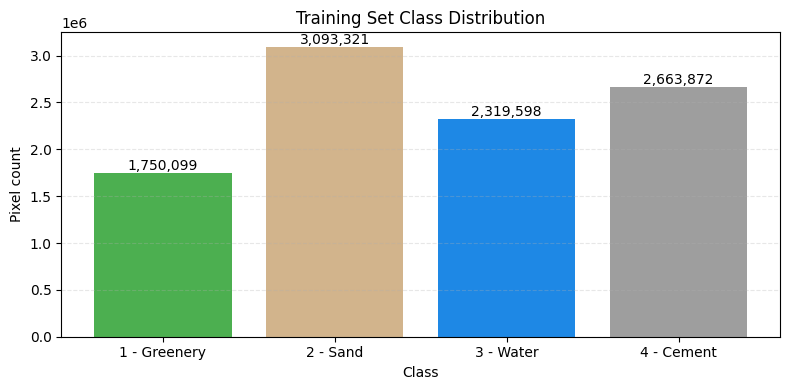

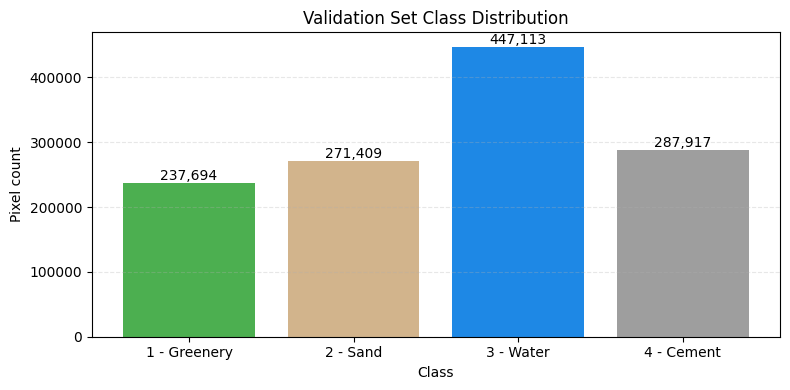

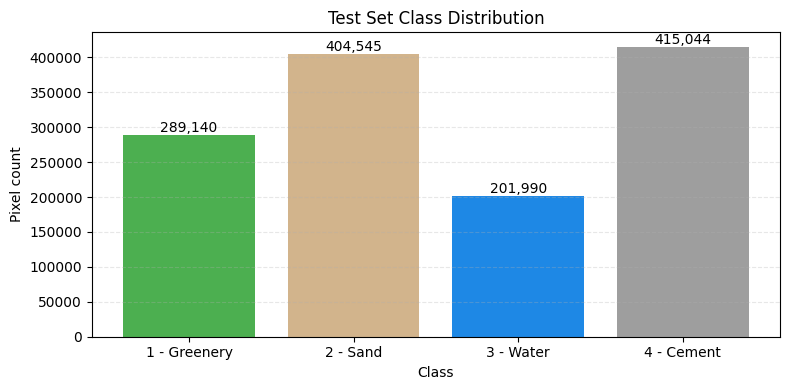

In [7]:
X_train, y_train = build_dataset(train_meta, train=True)
X_val, y_val = build_dataset(val_meta)
X_test, y_test = build_dataset(test_meta)

print('Train full:', X_train.shape, count_by_class(y_train[y_train != 0]))
print('Val full  :', X_val.shape, count_by_class(y_val[y_val != 0]))
print('Test full :', X_test.shape, count_by_class(y_test[y_test != 0]))

train_valid = y_train != 0
val_valid = y_val != 0
test_valid = y_test != 0

print('Ignored train pixels:', int((~train_valid).sum()))
plot_class_distribution(y_train[train_valid], 'Training Set Class Distribution')
plot_class_distribution(y_val[val_valid], 'Validation Set Class Distribution')
plot_class_distribution(y_test[test_valid], 'Test Set Class Distribution')

In [8]:
class SatelliteTrainTransform:
    def __init__(
        self,
        hflip_p=0.5,
        vflip_p=0.5,
        rotate_p=0.75,
        transpose_p=0.3,
        noise_p=0.2,
        intensity_p=0.2,
        noise_std=0.01,
        gain_range=(0.95, 1.05),
        bias_range=(-0.03, 0.03),
    ):
        self.hflip_p = hflip_p
        self.vflip_p = vflip_p
        self.rotate_p = rotate_p
        self.transpose_p = transpose_p
        self.noise_p = noise_p
        self.intensity_p = intensity_p
        self.noise_std = noise_std
        self.gain_range = gain_range
        self.bias_range = bias_range

    def __call__(self, img, mask):
        if random.random() < self.hflip_p:
            img = np.flip(img, axis=2)
            mask = np.flip(mask, axis=1)

        if random.random() < self.vflip_p:
            img = np.flip(img, axis=1)
            mask = np.flip(mask, axis=0)

        if random.random() < self.rotate_p:
            k = random.randint(0, 3)
            if k:
                img = np.rot90(img, k=k, axes=(1, 2))
                mask = np.rot90(mask, k=k, axes=(0, 1))

        if random.random() < self.transpose_p:
            img = np.transpose(img, (0, 2, 1))
            mask = np.transpose(mask, (1, 0))

        if random.random() < self.intensity_p:
            gain = np.float32(np.random.uniform(*self.gain_range))
            bias = np.float32(np.random.uniform(*self.bias_range))
            img = np.clip(img * gain + bias, 0.0, 1.0)

        if random.random() < self.noise_p:
            noise = np.random.normal(0.0, self.noise_std, size=img.shape).astype(np.float32)
            img = np.clip(img + noise, 0.0, 1.0)

        return img.astype(np.float32), mask.astype(np.int64)


train_transform = SatelliteTrainTransform()

train_ds = LandCoverSegDataset(X_train, y_train, transform=train_transform)
val_ds   = LandCoverSegDataset(X_val, y_val)
test_ds  = LandCoverSegDataset(X_test, y_test)


train_loader = DataLoader(
    train_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Train images with cement:', int(train_meta['has_cement'].sum()))
print('Train images with water :', int(train_meta['has_water'].sum()))

Dataset sizes: 153 19 20
Train images with cement: 141
Train images with water : 131


In [ ]:
class UNet(nn.Module):
    def __init__(self, encoder_name="resnet34", num_classes=5):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(12, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 12, kernel_size=1, bias=False),
            nn.BatchNorm2d(12),
            nn.ReLU(inplace=True),
        )

        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=12,
            classes=num_classes,
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.unet(x)
        return x


model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(config.DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=config.LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(
    ignore_index=config.IGNORE_INDEX
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")

24.478381 M parameters


In [11]:
images, masks = next(iter(train_loader))
images = images.to(config.DEVICE)
masks = masks.to(config.DEVICE)

with torch.no_grad():
    out = model(images)

print("Input shape :", images.shape)
print("Mask shape  :", masks.shape)
print("Output shape:", out.shape)

Input shape : torch.Size([8, 12, 256, 256])
Mask shape  : torch.Size([8, 256, 256])
Output shape: torch.Size([8, 5, 256, 256])


In [12]:
def compute_dataset_iou(conf_mat, ignore_index=0):
    ious = []

    for cls in range(conf_mat.shape[0]):
        if cls == ignore_index:
            continue

        tp = conf_mat[cls, cls]
        fp = conf_mat[:, cls].sum() - tp
        fn = conf_mat[cls, :].sum() - tp
        union = tp + fp + fn

        if union > 0:
            ious.append(tp / union)

    return float(np.mean(ious)) if ious else 0.0


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for images, masks in tqdm(loader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device, num_classes=5, ignore_index=0):
    model.eval()
    total_loss = 0.0
    conf_mat = np.zeros((num_classes, num_classes), dtype=np.int64)

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        preds = torch.argmax(logits, dim=1)
        valid = masks != ignore_index
        preds_valid = preds[valid]
        masks_valid = masks[valid]

        if masks_valid.numel() > 0:
            indices = (masks_valid.view(-1) * num_classes + preds_valid.view(-1)).to(torch.int64)
            batch_conf = torch.bincount(indices, minlength=num_classes * num_classes)
            conf_mat += batch_conf.reshape(num_classes, num_classes).cpu().numpy()

        total_loss += loss.item()

    mean_loss = total_loss / len(loader)
    mean_iou = compute_dataset_iou(conf_mat, ignore_index=ignore_index)
    return mean_loss, mean_iou, conf_mat

In [ ]:
num_epochs = 100
early_stopping_patience = 50
best_val_iou = -1.0
epochs_without_improvement = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, config.DEVICE)
    val_loss, val_iou, val_conf_mat = validate(
        model,
        val_loader,
        criterion,
        config.DEVICE,
        num_classes=config.NUM_CLASSES,
        ignore_index=config.IGNORE_INDEX,
    )
    scheduler.step(val_iou)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_mIoU={val_iou:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if val_iou > best_val_iou + 1e-4:
        best_val_iou = val_iou
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_unet.pth")
        print("Saved best model")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            print("Early stopping triggered")
            break

Training: 100%|██████████| 20/20 [00:03<00:00,  5.99it/s]


Epoch 1/100 | train_loss=1.3046 | val_loss=1.4294 | val_mIoU=0.1186 | lr=3.00e-04
Saved best model


Training: 100%|██████████| 20/20 [00:02<00:00,  6.72it/s]


Epoch 2/100 | train_loss=0.8486 | val_loss=0.7237 | val_mIoU=0.6560 | lr=3.00e-04
Saved best model


Training: 100%|██████████| 20/20 [00:02<00:00,  6.78it/s]


...

Epoch 98/100 | train_loss=0.2871 | val_loss=0.1736 | val_mIoU=0.8629 | lr=5.86e-07


Training: 100%|██████████| 20/20 [00:02<00:00,  6.90it/s]


Epoch 99/100 | train_loss=0.2428 | val_loss=0.1581 | val_mIoU=0.8752 | lr=5.86e-07


Training: 100%|██████████| 20/20 [00:02<00:00,  6.82it/s]


Epoch 100/100 | train_loss=0.2701 | val_loss=0.1682 | val_mIoU=0.8673 | lr=2.93e-07


In [19]:
checkpoint = torch.load("best_unet.pth", map_location=config.DEVICE)
model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(config.DEVICE)
model.load_state_dict(checkpoint)
model.eval()

UNet(
  (stem): Sequential(
    (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 12, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (7): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (unet): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(12, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1):

In [ ]:
val_loss, val_iou, val_conf_mat = validate(
    model,
    val_loader,
    criterion,
    config.DEVICE,
    num_classes=config.NUM_CLASSES,
    ignore_index=config.IGNORE_INDEX,
)
print(f"Validation | loss={val_loss:.4f} | mIoU={val_iou:.4f}")

for cls in range(config.NUM_CLASSES):
    if cls == config.IGNORE_INDEX:
        continue

    tp = val_conf_mat[cls, cls]
    fp = val_conf_mat[:, cls].sum() - tp
    fn = val_conf_mat[cls, :].sum() - tp
    union = tp + fp + fn
    class_iou = tp / union if union > 0 else float('nan')
    print(f"  {config.CLASS_NAMES[cls]} IoU: {class_iou:.4f}")

Validation | loss=0.1470 | mIoU=0.8845
  Greenery IoU: 0.8689
  Sand IoU: 0.8708
  Water IoU: 0.9869
  Cement IoU: 0.8114


In [ ]:
test_loss, test_iou, test_conf_mat = validate(
    model,
    test_loader,
    criterion,
    config.DEVICE,
    num_classes=config.NUM_CLASSES,
    ignore_index=config.IGNORE_INDEX,
)
print(f"Test | loss={test_loss:.4f} | mIoU={test_iou:.4f}")

for cls in range(config.NUM_CLASSES):
    if cls == config.IGNORE_INDEX:
        continue

    tp = test_conf_mat[cls, cls]
    fp = test_conf_mat[:, cls].sum() - tp
    fn = test_conf_mat[cls, :].sum() - tp
    union = tp + fp + fn
    class_iou = tp / union if union > 0 else float('nan')
    print(f"  {config.CLASS_NAMES[cls]} IoU: {class_iou:.4f}")

Test | loss=0.2281 | mIoU=0.8606
  Greenery IoU: 0.8831
  Sand IoU: 0.8201
  Water IoU: 0.9653
  Cement IoU: 0.7738


In [22]:
@torch.no_grad()
def show_prediction(model, split_df, idx=0):
    if isinstance(model, dict):
        loaded_model = UNet(
            encoder_name="resnet34",
            num_classes=5
        ).to(config.DEVICE)
        loaded_model.load_state_dict(model)
        model = loaded_model

    model.eval()

    row = split_df.iloc[idx]
    image_np, mask_np, _ = preprocess_img(row["img_path"], row["mask_path"])

    x = torch.from_numpy(image_np.astype(np.float32)).unsqueeze(0).to(config.DEVICE)

    logits = model(x)
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    mask_values, mask_counts = np.unique(mask_np, return_counts=True)
    pred_values, pred_counts = np.unique(pred, return_counts=True)

    print("Mask: ", dict(zip(mask_values, mask_counts)))
    print("Prediction: ", dict(zip(pred_values, pred_counts)))

    rgb = np.transpose(image_np[[3, 2, 1]], (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="tab10", vmin=0, vmax=4)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred, cmap="tab10", vmin=0, vmax=4)
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

Mask:  {np.uint8(1): np.int64(72835), np.uint8(2): np.int64(1399), np.uint8(3): np.int64(618), np.uint8(4): np.int64(28090)}
Prediction:  {np.int64(1): np.int64(71726), np.int64(2): np.int64(18), np.int64(3): np.int64(366), np.int64(4): np.int64(30832)}


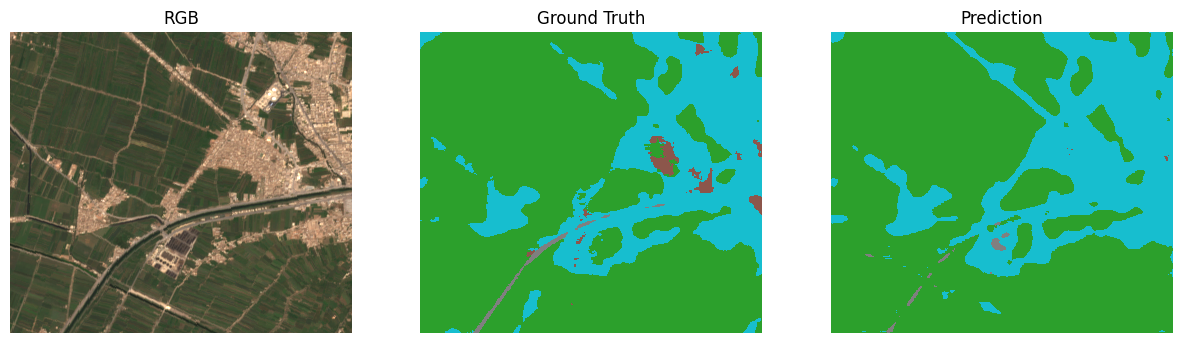

In [23]:
show_prediction(model, train_meta, idx=147)